# Alethe × dbt — point-in-time honesty across a real lakehouse DAG

This notebook is a **proof of concept** for the Observability Watermark Specification (OWS)
wired into a real dbt project. Everything below executes against **real infrastructure**:
a real Delta table (delta-rs) that really gets `VACUUM`ed, a real Apache Iceberg table
(pyiceberg + SqlCatalog) whose old data files really get destroyed, real `dbt snapshot`
runs, and a real `dbt run` materializing the full DAG on duckdb.

**Layering** (explicit source → staging → fact/dim):

```
delta://orders  (REAL Delta table)     ─┐
iceberg://raw.returns (REAL Iceberg)   ─┼─ sources (watermarked by alethe)
raw.customers  (mutable dimension)     ─┘
        │                │                      │
   stg_orders       stg_returns          customers_snapshot (SCD2)
        │                │                      │ stg_customers
        └── fct_orders ──┘                dim_customer
                 └────── revenue_by_segment ─────┘   (+ dim_date seed)
```

**One deliberate compromise, stated up front:** dbt executes against duckdb, and duckdb
has no native Delta/Iceberg time travel — so the duckdb `raw` schema *mirrors the current
state* of the lake tables. In production the sources **are** the lake tables (Spark/Trino
read both formats natively). The **watermarks, boundaries and probes here always come from
the real Delta/Iceberg tables**, never from the mirror.

| Scenario | Claim |
|---|---|
| S1 | The transaction log lists versions that no longer physically exist ("the lie") |
| S2 | alethe derives the boundary and validates it *empirically* (read v9 OK, v8 fails) |
| S3 | `alethe report` over the real dbt manifest; twice-temporal check from `run_results.json` |
| S4 | `rewrite_model` binds compiled SQL at CERTAIN / BOUNDED / UNACHIEVABLE times |
| S5 | The dbt macro shim adds engine-native `AS OF` / SCD2 validity at compile time |
| S6 | dbt snapshots preserve mutation history that storage time travel has destroyed |
| S7 | Iceberg suffix boundary + readable islands; weakest-link composition across chains |

In [1]:
%matplotlib inline
import json
import os
import sys
import warnings
from datetime import datetime, timedelta, timezone

sys.path.insert(0, os.getcwd())

import pandas as pd

pd.set_option('display.width', 160)
pd.set_option('display.max_rows', 60)
pd.set_option('display.max_colwidth', 90)

import alethe
import poc_support as ps

print('python :', sys.executable)
print('alethe :', alethe.__version__)
ps.reset_workspace()
print('workspace reset:', ps.DATA)

python : /Users/seamusaran/Documents/alethe/.venv/bin/python
alethe : 0.1.0
workspace reset: /Users/seamusaran/Documents/alethe/poc/dbt/data


## Phase 0 — build the real Delta source: 20 day-versions, vacuum mid-history

20 overwrite commits, one per synthetic business day (2026-06-01 … 06-20), 1s apart so
every commit has a distinct real timestamp. After writing **version 9** we run a real
`VACUUM` with `retention_hours=0`, physically deleting the data files of versions 0–8,
then keep writing. The vacuum itself commits `VACUUM START`/`VACUUM END` entries, so the
log grows past 20 versions — which is part of the point.

In [2]:
build = ps.build_orders_delta()
writes = build['writes']
orders_df = build['orders']
print(f"performed {len(writes)} daily overwrite commits, {len(orders_df)} orders total")
print('vacuum:', build['vacuum'])
pd.DataFrame(writes).tail(3)

performed 20 daily overwrite commits, 113 orders total
vacuum: {'after_version': 9, 'files_deleted': 9, 'vacuum_at': datetime.datetime(2026, 7, 7, 23, 20, 46, 634011, tzinfo=datetime.timezone.utc)}


,day_index,day,version,rows,committed_at
17,17,2026-06-18,19,107,2026-07-07 23:20:53.804000+00:00
18,18,2026-06-19,20,110,2026-07-07 23:20:54.833000+00:00
19,19,2026-06-20,21,113,2026-07-07 23:20:55.860000+00:00


## S1 — the lie: the log lists versions that are physically gone

**Claim.** After VACUUM, `_delta_log` still lists every version ever committed, and
metadata operations on old versions succeed — but *reading* them fails, because the data
files were destroyed. The log answers "what happened"; it no longer proves "what can be
read". Every per-version probe below is a real end-to-end read attempt.

In [3]:
probe = ps.probe_versions(ps.ORDERS_DELTA)
listed = len(probe)
readable = int(probe.readable.sum())
print(f"log lists {listed} versions; physically readable: {readable}")
assert listed >= 20 and readable < listed, 'expected destroyed versions below the boundary'
probe

log lists 22 versions; physically readable: 13


,version,operation,readable,detail
0,0,WRITE,False,FileNotFoundError
1,1,WRITE,False,FileNotFoundError
2,2,WRITE,False,FileNotFoundError
3,3,WRITE,False,FileNotFoundError
4,4,WRITE,False,FileNotFoundError
5,5,WRITE,False,FileNotFoundError
6,6,WRITE,False,FileNotFoundError
7,7,WRITE,False,FileNotFoundError
8,8,WRITE,False,FileNotFoundError
9,9,WRITE,True,63 rows


**Conclusion.** The log lists every commit ever made (22 here: 20 writes plus the
vacuum's own commits) — but every write before v9 fails a real read, because its files
are gone. Any system that answers time-travel questions from metadata alone is lying
about the destroyed prefix.

## S2 — the oracle: boundary v9, validated empirically, corroborated twice

**Claim.** `alethe.watermark()` derives the boundary by replaying `_delta_log` against
file existence, cross-checks it against the log's own `VACUUM END` records (two
*independent* derivations), and then **validates it empirically**: a real read at the
boundary must succeed and a real read at boundary−1 must fail. Metadata arithmetic alone
is never trusted (spec §2).

In [4]:
wm_orders = alethe.watermark(ps.ORDERS_DELTA)
print(wm_orders.chain, '->', wm_orders.boundary,
      '| grade:', wm_orders.evidence_grade.value,
      '| empirically_validated:', wm_orders.empirically_validated)
print('boundary_dt        :', wm_orders.boundary_dt.isoformat())
print('earliest_dt        :', wm_orders.earliest_dt.isoformat())
print('claim_recorded_at  :', wm_orders.claim_recorded_at.isoformat(),
      ' (attested-since != true-since)')
print('proof:', json.dumps(wm_orders.proof, indent=2, default=str))

b = wm_orders.boundary['version']
ok_b, detail_b = ps.read_version(ps.ORDERS_DELTA, b)
ok_prev, detail_prev = ps.read_version(ps.ORDERS_DELTA, b - 1)
print(f"empirical validation: read v{b} -> {'OK' if ok_b else 'FAIL'} ({detail_b}); "
      f"read v{b-1} -> {'OK' if ok_prev else 'FAIL'} ({detail_prev})")

assert b == 9, f'recipe expects boundary v9, got v{b}'
assert wm_orders.empirically_validated
assert wm_orders.proof['corroborated'], 'file-existence and vacuum-commit derivations must agree'
assert ok_b and not ok_prev

delta://orders -> {'version': 9} | grade: derived | empirically_validated: True
boundary_dt        : 2026-07-07T23:20:45.609000+00:00
earliest_dt        : 2026-07-07T23:20:36.452000+00:00
claim_recorded_at  : 2026-07-07T23:20:57.005502+00:00  (attested-since != true-since)
proof: {
  "derivation_file_existence": 9,
  "derivation_vacuum_commits": 9,
  "corroborated": true,
  "vacuum_end_versions": [
    11
  ]
}
empirical validation: read v9 -> OK (63 rows); read v8 -> FAIL (FileNotFoundError)


### The timestamp pitfall (deliberate, not a bug)

`DeltaTable.load_as_version(timestamp)` resolves timestamps **into vacuumed versions**
without complaint — the failure only surfaces at read time. This is exactly the silent
conflation OWS exists to make legible: "resolvable in metadata" ≠ "readable".

In [5]:
target_ts = writes[3]['committed_at'] + timedelta(milliseconds=200)
pitfall = ps.timestamp_pitfall(ps.ORDERS_DELTA, target_ts)
print(f"load_as_version({target_ts.isoformat()}) resolved to v{pitfall['resolved_version']} without error")
assert not pitfall['read_ok'], 'reading a vacuumed version should fail'
print(f"...but the read raised {pitfall['error_type']}: {pitfall['error']}")

entry = alethe.record(wm_orders, ps.WATERMARKS)
print('recorded watermark in hash-chained manifest: seq', entry['seq'], 'hash', entry['hash'])

load_as_version(2026-07-07T23:20:39.698000+00:00) resolved to v3 without error
...but the read raised FileNotFoundError: Object at location /Users/seamusaran/Documents/alethe/poc/dbt/data/lakehouse/orders/part-00000-9431edc1-add2-400b-80a6-1506e29ff1b6-c000.snappy.parquet not found
                    ↳ No such file or directory (os error 2)

recorded watermark in hash-chained manifest: seq 0 hash 9aa1c80b4f4a450b


### V1 — the orders chain, drawn honestly

Green dots: versions a real read succeeds on. Red ×: versions the log lists but VACUUM
destroyed. Bands: the three PIT zones the watermark induces.

saved img/v1_orders_timeline.png


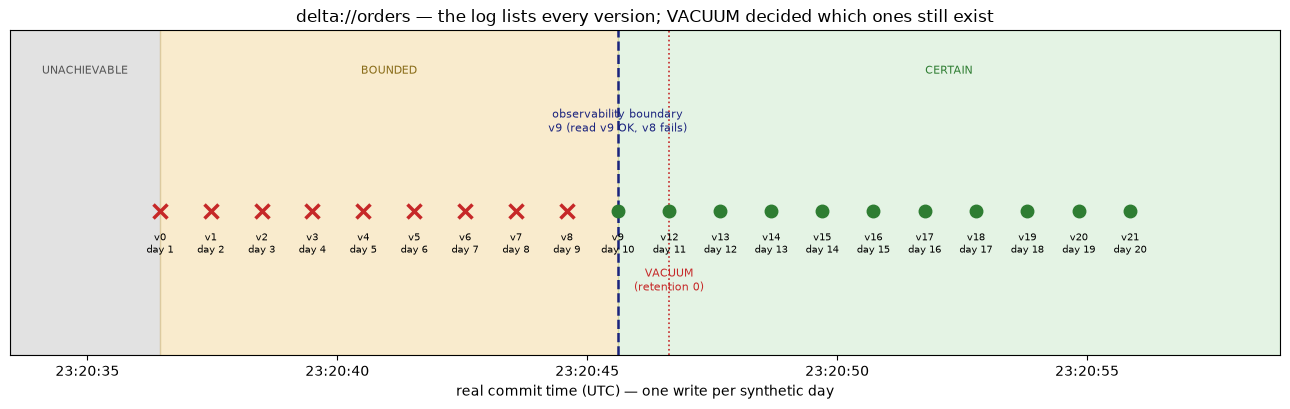

In [6]:
fig = ps.plot_v1(writes, build['vacuum'], wm_orders, probe)
assert (ps.IMG / 'v1_orders_timeline.png').exists()
print('saved img/v1_orders_timeline.png')

## Phase 1 — build the real Iceberg source: raw.returns

Six cumulative ingest batches via `tbl.overwrite(...)` (pyiceberg, sqlite SqlCatalog),
1s apart. Then old data files are destroyed **out-of-band** — keeping only files
referenced by the last two snapshots — exactly what an aggressive
`expire_snapshots` + `remove_orphan_files` pass does in production.

In [7]:
returns_df, batch_log = ps.build_returns_iceberg(orders_df)
display(pd.DataFrame(batch_log))
destruction = ps.destroy_old_iceberg_files(keep_last=2)
print(f"snapshots in metadata: {len(destruction['snapshots'])}; "
      f"data files kept: {destruction['kept_files']}; destroyed: {destruction['destroyed_files']}")
destruction['snapshots']

/Users/seamusaran/Documents/alethe/.venv/lib/python3.13/site-packages/pyiceberg/table/__init__.py:639: UserWarning: Delete operation did not match any records
  self.delete(


,batch,cutoff,rows
0,1,2026-06-05,5
1,2,2026-06-09,10
2,3,2026-06-13,14
3,4,2026-06-17,18
4,5,2026-06-21,24
5,6,2026-06-28,24


snapshots in metadata: 11; data files kept: 1; destroyed: 5


,sequence_number,snapshot_id,operation,committed_at
0,1,2651284075581644882,append,2026-07-07 23:20:57.351000+00:00
1,2,3510358560471228347,delete,2026-07-07 23:20:58.381000+00:00
2,3,1517106723067886667,append,2026-07-07 23:20:58.390000+00:00
3,4,3985820933806776303,delete,2026-07-07 23:20:59.415000+00:00
4,5,655680941830872761,append,2026-07-07 23:20:59.425000+00:00
5,6,2872082438059862377,delete,2026-07-07 23:21:00.452000+00:00
6,7,2667261512614618083,append,2026-07-07 23:21:00.463000+00:00
7,8,8079603561209434815,delete,2026-07-07 23:21:01.491000+00:00
8,9,5410882079465287525,append,2026-07-07 23:21:01.503000+00:00
9,10,6263077605288874702,delete,2026-07-07 23:21:02.528000+00:00


## S7a — the Iceberg watermark: suffix boundary and readable islands

**Claim.** Readability is **not monotone** in position. Iceberg overwrites are
delete+append pairs, so empty intermediate snapshots stay trivially readable *between*
destroyed ones. OWS boundary uses **suffix semantics**: the earliest snapshot from which
*all later* snapshots read successfully. Readable islands below the boundary are recorded
in `proof` but MUST NOT extend the claim (spec §2).

In [8]:
wm_returns = alethe.watermark('raw.returns', adapter='iceberg', catalog=ps.get_catalog())
print(wm_returns.chain)
print('boundary (suffix)      :', wm_returns.boundary)
print('boundary_dt            :', wm_returns.boundary_dt.isoformat())
print('empirically_validated  :', wm_returns.empirically_validated)
print(f"readable islands below the boundary: {len(wm_returns.readable_islands)}")
for isl in wm_returns.readable_islands:
    print('  island:', isl)
print('per-snapshot probes (the empirical evidence):')
print(json.dumps(wm_returns.proof['per_snapshot'], indent=2))

assert wm_returns.empirically_validated
assert wm_returns.boundary_dt > wm_orders.boundary_dt, 'iceberg chain should be the younger boundary'
entry = alethe.record(wm_returns, ps.WATERMARKS)
print('recorded: seq', entry['seq'], 'hash', entry['hash'])

iceberg://raw.returns
boundary (suffix)      : {'snapshot_id': '6263077605288874702', 'sequence_number': 10, 'timestamp_ms': 1783466462528}
boundary_dt            : 2026-07-07T23:21:02.528000+00:00
empirically_validated  : True
readable islands below the boundary: 4
  island: {'snapshot_id': '3510358560471228347', 'sequence_number': 2}
  island: {'snapshot_id': '3985820933806776303', 'sequence_number': 4}
  island: {'snapshot_id': '2872082438059862377', 'sequence_number': 6}
  island: {'snapshot_id': '8079603561209434815', 'sequence_number': 8}
per-snapshot probes (the empirical evidence):
{
  "2651284075581644882": "UNREADABLE (FileNotFoundError)",
  "3510358560471228347": "READABLE (read 0 rows)",
  "1517106723067886667": "UNREADABLE (FileNotFoundError)",
  "3985820933806776303": "READABLE (read 0 rows)",
  "655680941830872761": "UNREADABLE (FileNotFoundError)",
  "2872082438059862377": "READABLE (read 0 rows)",
  "2667261512614618083": "UNREADABLE (FileNotFoundError)",
  "8079603561

## Phase 2 — mirror current lake state into duckdb; seed the calendar

duckdb gets the *current* state of both lake tables in schema `raw` so `dbt run` can
genuinely materialize the whole DAG. History and watermarks stay with the real lake
tables — the mirror is a compute convenience, and is documented as such in `schema.yml`.

In [9]:
print(ps.mirror_lake_to_duckdb())
res = ps.run_dbt('seed', echo_tail=4)

{'orders_rows': 113, 'returns_rows': 24}


23:21:05  
23:21:05  Completed successfully
23:21:05  
23:21:05  Done. PASS=1 WARN=0 ERROR=0 SKIP=0 NO-OP=0 TOTAL=1


## Phase 3 — customers: four real mutations, four real `dbt snapshot` runs

Customer **C03** walks `trial → consumer → smb → enterprise`. For each state we
(1) overwrite a REAL Delta mirror at `data/lakehouse/customers`, (2) overwrite duckdb
`raw.customers`, (3) run `dbt snapshot` (strategy=`check`, `check_cols='all'`), and
(4) capture a wall-clock probe timestamp inside that state's validity window.
After state 2, the Delta mirror is **vacuumed** — destroying state 1's files for real —
which sets up S6: storage forgets, the snapshot remembers.

In [10]:
phase = ps.run_customers_phase()
print('probe timestamps :', {s: t.strftime('%H:%M:%S.%f')[:-3] for s, t in phase['ts_probe'].items()})
print('delta versions   :', phase['delta_versions'])
print('vacuum           :', phase['vacuum'])
ps.customers_state(4)

probe timestamps : {1: '23:21:07.060', 2: '23:21:10.123', 3: '23:21:13.188', 4: '23:21:16.264'}
delta versions   : {1: 0, 2: 1, 3: 4, 4: 5}
vacuum           : {'after_state': 2, 'files_deleted': 1}


,customer_id,customer_name,segment,region
0,C01,Aster Analytics,smb,emea
1,C02,Birch & Co,consumer,apac
2,C03,Cobalt Retail,enterprise,amer
3,C04,Damson Foods,enterprise,emea
4,C05,Elder Logistics,smb,apac
5,C06,Foxglove Media,enterprise,amer
6,C07,Gorse Mining,enterprise,apac
7,C08,Hazel Health,consumer,emea


In [11]:
ref_ts = phase['ts_probe'][1]
hist_all = ps.load_snapshot_history(reference=ref_ts)
hist_c03 = ps.load_snapshot_history(ps.FOCUS_CUSTOMER, reference=ref_ts)
display(hist_c03)
assert len(hist_c03) == 4, 'C03 should have four SCD2 versions'

# Watermark the snapshot chain (manually constructed: row-space evidence is
# witnessed, not derived) and the vacuumed Delta mirror of the same table.
wm_snapshot = ps.make_snapshot_watermark(hist_all, ref_ts)
wm_customers = alethe.watermark(ps.CUSTOMERS_DELTA)
print('snapshot chain  :', wm_snapshot.chain, wm_snapshot.boundary,
      wm_snapshot.evidence_grade.value, wm_snapshot.boundary_dt.isoformat())
print('customers delta :', wm_customers.chain, wm_customers.boundary,
      '| validated:', wm_customers.empirically_validated,
      '| boundary_dt:', wm_customers.boundary_dt.isoformat())
assert wm_customers.boundary['version'] == 1, 'vacuum after state 2 leaves v1 as the boundary'
for wm in (wm_customers, wm_snapshot):
    e = alethe.record(wm, ps.WATERMARKS)
    print('recorded', wm.chain, '-> seq', e['seq'])

,customer_id,customer_name,segment,region,dbt_valid_from,dbt_valid_to,valid_from_utc,valid_to_utc
0,C03,Cobalt Retail,trial,amer,2026-07-07 18:21:06.851792,2026-07-07 18:21:09.872205,2026-07-07 23:21:06.851792+00:00,2026-07-07 23:21:09.872205+00:00
1,C03,Cobalt Retail,consumer,amer,2026-07-07 18:21:09.872205,2026-07-07 18:21:12.941533,2026-07-07 23:21:09.872205+00:00,2026-07-07 23:21:12.941533+00:00
2,C03,Cobalt Retail,smb,amer,2026-07-07 18:21:12.941533,2026-07-07 18:21:15.999256,2026-07-07 23:21:12.941533+00:00,2026-07-07 23:21:15.999256+00:00
3,C03,Cobalt Retail,enterprise,amer,2026-07-07 18:21:15.999256,NaT,2026-07-07 23:21:15.999256+00:00,NaT


snapshot chain  : snapshot://customers_snapshot {'run': 'first'} witnessed-fresh 2026-07-07T23:21:06.851792+00:00
customers delta : delta://customers {'version': 1} | validated: True | boundary_dt: 2026-07-07T23:21:08.579000+00:00
recorded delta://customers -> seq 2
recorded snapshot://customers_snapshot -> seq 3


## Phase 4 — `dbt run`: materialize the full DAG

Staging is ephemeral (inlined), so `dbt run` builds `fct_orders`, `dim_customer` and
`revenue_by_segment` — the fact/dim/mart layer — on top of the seeded calendar and the
SCD2 snapshot.

In [12]:
res = ps.run_dbt('run', echo_tail=10)
con = ps.duckdb_con(read_only=True)
print(con.execute('select count(*) as fct_rows from main.fct_orders').fetch_df())
display(con.execute('select * from main.revenue_by_segment limit 8').fetch_df())
con.close()

23:21:19  2 of 3 START sql table model main.fct_orders ................................... [RUN]
23:21:19  2 of 3 OK created sql table model main.fct_orders .............................. [OK in 0.01s]
23:21:19  3 of 3 START sql table model main.revenue_by_segment ........................... [RUN]
23:21:19  3 of 3 OK created sql table model main.revenue_by_segment ...................... [OK in 0.01s]
23:21:19  
23:21:19  Finished running 3 table models in 0 hours 0 minutes and 0.14 seconds (0.14s).
23:21:19  
23:21:19  Completed successfully
23:21:19  
23:21:19  Done. PASS=3 WARN=0 ERROR=0 SKIP=0 NO-OP=0 TOTAL=3
   fct_rows
0       113


,date_day,is_weekend,segment,order_count,gross_revenue,refunds,net_revenue
0,2026-06-01,False,consumer,2,273.89,110.05,163.84
1,2026-06-01,False,enterprise,3,512.04,151.28,360.76
2,2026-06-01,False,smb,3,377.65,39.65,338.00
3,2026-06-02,False,enterprise,5,910.21,63.14,847.07
4,2026-06-02,False,smb,2,635.93,0.00,635.93
5,2026-06-03,False,consumer,1,223.77,167.21,56.56
6,2026-06-03,False,enterprise,2,289.33,34.71,254.62
7,2026-06-03,False,smb,2,661.88,0.00,661.88


## S3 — `alethe report` over the real dbt manifest

**Claim.** From `target/manifest.json` + the recorded watermark ledger, alethe walks the
DAG of every model to its leaves (sources and snapshots — resolved via
`meta.alethe.chain`), composes weakest-link PIT reports, and checks the **twice-temporal**
condition from `run_results.json`: was the model materialized while its upstreams were
still within retention?

The `check`-strategy warning on the snapshot chain in stderr is **expected and correct**:
check-strategy snapshots witness state at run time and cannot reconstruct between-run
states.

In [13]:
res = ps.run_alethe_cli('report',
                        '--dbt-manifest', 'project/target/manifest.json',
                        '--watermarks', str(ps.WATERMARKS),
                        '--run-results', 'project/target/run_results.json')
print(res.stdout)
if res.stderr.strip():
    print('--- stderr (expected check-strategy warnings) ---')
    print(ps.tail(res.stderr, 4))
assert res.returncode == 0, res.stderr

PIT Achievability Report: dim_customer
────────────────────────────────────────────────────────
Upstream chain                       Boundary                 Grade
  snapshot://customers_snapshot      2026-07-07 23:21:06      witnessed-fresh ← limiting
────────────────────────────────────────────────────────
Effective boundary:  2026-07-07 23:21:06  (limiting: snapshot://customers_snapshot)
Effective grade:     witnessed-fresh
Materialization:     2026-07-07 23:21:19  [twice-temporal: CONFORMANT]

PIT zones:
  CERTAIN        2026-07-07 23:21:06 → now
  BOUNDED        2026-07-07 23:21:06 → 2026-07-07 23:21:06  limiting: ['snapshot://customers_snapshot']
  UNACHIEVABLE   −∞ → 2026-07-07 23:21:06  limiting: ['snapshot://customers_snapshot']

PIT Achievability Report: fct_orders
────────────────────────────────────────────────────────
Upstream chain                       Boundary                 Grade
  delta://orders                     2026-07-07 23:20:45      derived
  iceberg://raw.ret

In [14]:
from alethe.integrations import DbtLineage

chains = alethe.load_watermarks(ps.WATERMARKS)
lineage = DbtLineage('project/target/manifest.json')
print(lineage)

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter('always')
    wms_fct = lineage.resolve_watermarks('fct_orders', chains)
    report_fct = lineage.pit_report('fct_orders', watermarks=wms_fct,
                                    run_results_path='project/target/run_results.json')
    wms_rbs = lineage.resolve_watermarks('revenue_by_segment', chains)
    report_rbs = lineage.pit_report('revenue_by_segment', watermarks=wms_rbs,
                                    run_results_path='project/target/run_results.json')
print(report_fct)
print()
print(report_rbs)
print()
print('expected warnings:', sorted({str(w.message)[:95] for w in caught}))
print('twice-temporal conformant (fct_orders):', report_fct.materialization_conformant)
assert report_fct.materialization_conformant is True
assert report_rbs.materialization_conformant is True

DbtLineage('manifest.json', 6 models, 4 leaf nodes, schema='https://schemas.getdbt.com/dbt/manifest/v12.json')
PIT Achievability Report: fct_orders
────────────────────────────────────────────────────────
Upstream chain                       Boundary                 Grade
  delta://orders                     2026-07-07 23:20:45      derived
  iceberg://raw.returns              2026-07-07 23:21:02      derived ← limiting
────────────────────────────────────────────────────────
Effective boundary:  2026-07-07 23:21:02  (limiting: iceberg://raw.returns)
Effective grade:     derived
Materialization:     2026-07-07 23:21:19  [twice-temporal: CONFORMANT]

PIT zones:
  CERTAIN        2026-07-07 23:21:02 → now
  BOUNDED        2026-07-07 23:20:57 → 2026-07-07 23:21:02  limiting: ['iceberg://raw.returns']
  UNACHIEVABLE   −∞ → 2026-07-07 23:20:57  limiting: ['iceberg://raw.returns']

PIT Achievability Report: revenue_by_segment
────────────────────────────────────────────────────────
Upstream c

### Zone verdicts and the CI gate

Three timestamps, one per zone, computed **from the report itself** (never hardcoded).
`alethe check` is the CI form: exit 0 = CERTAIN, 1 = BOUNDED without `--allow-bounded`,
2 = UNACHIEVABLE. Overrides are "sign for the exception", never "disable the gate" —
`--allow-bounded --record` writes a materialization-snapshot into the hash chain.

In [15]:
certain_ts = datetime.now(tz=timezone.utc)
bounded_ts = report_fct.earliest_dt + (report_fct.effective_boundary - report_fct.earliest_dt) / 2
unachievable_ts = report_fct.earliest_dt - timedelta(minutes=5)

for label, ts in [('CERTAIN     ', certain_ts), ('BOUNDED     ', bounded_ts),
                  ('UNACHIEVABLE', unachievable_ts)]:
    z = report_fct.query(ts)
    print(f"{label} as-of {ts.isoformat()} -> {z.status.value:12s} limiting: {z.limiting_chains}")
assert report_fct.query(certain_ts).status.value == 'CERTAIN'
assert report_fct.query(bounded_ts).status.value == 'BOUNDED'
assert report_fct.query(unachievable_ts).status.value == 'UNACHIEVABLE'

gate = ps.run_alethe_cli('check', '--dbt-manifest', 'project/target/manifest.json',
                         '--model', 'fct_orders', '--as-of', bounded_ts.isoformat(),
                         '--watermarks', str(ps.WATERMARKS))
print('alethe check (BOUNDED, no override) exit code:', gate.returncode)
gate2 = ps.run_alethe_cli('check', '--dbt-manifest', 'project/target/manifest.json',
                          '--model', 'fct_orders', '--as-of', bounded_ts.isoformat(),
                          '--watermarks', str(ps.WATERMARKS), '--allow-bounded', '--record')
print('alethe check (BOUNDED, --allow-bounded --record) exit code:', gate2.returncode)
print(ps.tail(gate2.stdout, 5))
assert gate.returncode == 1 and gate2.returncode == 0

CERTAIN      as-of 2026-07-07T23:21:19.381242+00:00 -> CERTAIN      limiting: []
BOUNDED      as-of 2026-07-07T23:20:59.939500+00:00 -> BOUNDED      limiting: ['iceberg://raw.returns']
UNACHIEVABLE as-of 2026-07-07T23:15:57.351000+00:00 -> UNACHIEVABLE limiting: ['iceberg://raw.returns']
alethe check (BOUNDED, no override) exit code: 1
alethe check (BOUNDED, --allow-bounded --record) exit code: 0
  CERTAIN        2026-07-07 23:21:02 → now
  BOUNDED        2026-07-07 23:20:57 → 2026-07-07 23:21:02  limiting: ['iceberg://raw.returns']
  UNACHIEVABLE   −∞ → 2026-07-07 23:20:57  limiting: ['iceberg://raw.returns']
recorded materialization-snapshot: seq=4 hash=eaa6bfd3fcbc534b
BOUNDED — retention has destroyed part of ['iceberg://raw.returns'] at 2026-07-07T23:20:59.939500+00:00. Monotone aggregates are lower bounds; non-monotone queries are unsound.


## S4 — PIT query rewriting, gated by the report

**Claim.** `rewrite_model` takes the model's *compiled* SQL and binds every physical
leaf to a point in time: sources get engine-native `TIMESTAMP AS OF` (Spark dialect
here); snapshot upstreams get SCD2 validity predicates — because their history lives in
rows, and time-travelling a snapshot table would be a category error. A CERTAIN time
rewrites cleanly; a BOUNDED time rewrites **with a warning**; an UNACHIEVABLE time
**raises** instead of producing a silently-empty answer.

In [16]:
r_certain = lineage.rewrite_model('fct_orders', certain_ts, watermarks=wms_fct,
                                  compiled_sql=ps.compiled_model_sql('fct_orders'),
                                  dialect='spark')
print('status:', r_certain.status, '| bound tables:', r_certain.bound_tables)
print('warnings:', r_certain.warnings)
print(r_certain.sql)
assert str(r_certain.status.value) == 'CERTAIN'
assert 'TIMESTAMP AS OF' in r_certain.sql
assert len(r_certain.bound_tables) == 2, 'both delta and iceberg sources must be bound'

status: PitStatus.CERTAIN | bound tables: ['pit_poc.raw.orders', 'pit_poc.raw.returns']
warnings: []
WITH __dbt__cte__stg_orders AS (
  /* Staging over the Delta-backed source. Ephemeral: this SELECT is inlined */
  /* into downstream compiled SQL, so `pit_poc.raw.orders` appears verbatim */
  /* where the alethe PIT rewriter / macro shim can bind it. */
  SELECT
    order_id,
    customer_id,
    CAST(order_date AS DATE) AS order_date,
    CAST(amount AS DOUBLE) AS amount
  FROM `pit_poc`.`raw`.`orders` TIMESTAMP AS OF CAST('2026-07-07 23:21:19' AS TIMESTAMP)
), __dbt__cte__stg_returns /* Fact: order grain, joined to returns for net revenue. */ AS (
  /* Staging over the Iceberg-backed source. Ephemeral, same rationale as */
  /* stg_orders: the physical relation must be visible in compiled SQL for */
  /* point-in-time binding to reach it. */
  SELECT
    return_id,
    order_id,
    CAST(return_date AS DATE) AS return_date,
    CAST(refund_amount AS DOUBLE) AS refund_amount,
    rea

In [17]:
r_bounded = lineage.rewrite_model('fct_orders', bounded_ts, watermarks=wms_fct,
                                  compiled_sql=ps.compiled_model_sql('fct_orders'),
                                  dialect='spark')
print('status:', r_bounded.status)
for w in r_bounded.warnings:
    print(' warning:', w)
assert str(r_bounded.status.value) == 'BOUNDED' and len(r_bounded.warnings) >= 1

status: PitStatus.BOUNDED


In [18]:
from alethe.integrations import UnachievableQueryError

try:
    lineage.rewrite_model('fct_orders', unachievable_ts, watermarks=wms_fct,
                          compiled_sql=ps.compiled_model_sql('fct_orders'),
                          dialect='spark')
    raise AssertionError('expected UnachievableQueryError')
except UnachievableQueryError as e:
    print('REFUSED, as it must be:')
    print(' ', e)

REFUSED, as it must be:
  AS OF 2026-07-07T23:15:57.351000+00:00 precedes the existence of ['iceberg://raw.returns']. No honest rewrite is possible — the population itself is unknowable at that time (spec §9).


In [19]:
# Snapshot upstream -> SCD2 validity predicate, not TIMESTAMP AS OF.
wms_dim = lineage.resolve_watermarks('dim_customer', chains)
r_dim = lineage.rewrite_model('dim_customer', phase['ts_probe'][2], watermarks=wms_dim,
                              compiled_sql=ps.compiled_model_sql('dim_customer'),
                              dialect='spark')
print('bound tables:', r_dim.bound_tables)
print(r_dim.sql)
assert any('(scd2)' in b for b in r_dim.bound_tables)
assert 'dbt_valid_from' in r_dim.sql and 'TIMESTAMP AS OF' not in r_dim.sql

# Honest limitation, shown deliberately: revenue_by_segment reads MATERIALIZED
# fct/dim tables, so no physical leaf appears in its own compiled SQL — there is
# nothing to bind, and alethe says so instead of pretending.
r_rbs = lineage.rewrite_model('revenue_by_segment', certain_ts, watermarks=wms_rbs,
                              compiled_sql=ps.compiled_model_sql('revenue_by_segment'),
                              dialect='spark')
print('revenue_by_segment bound:', r_rbs.bound_tables,
      '| unmatched tracked:', r_rbs.unmatched_tracked)
for w in r_rbs.warnings:
    print(' warning:', w)
assert r_rbs.bound_tables == [] and len(r_rbs.unmatched_tracked) >= 2

bound tables: ['pit_poc.main_snapshots.customers_snapshot (scd2)']
WITH __dbt__cte__stg_customers /* Type-2 customer dimension. Carries the FULL SCD2 history (no */ AS (
  /* History-preserving staging: reads the SCD2 snapshot, not the mutable */
  /* raw.customers table. History lives in ROWS (dbt_valid_from / */
  /* dbt_valid_to), so it survives any storage-level VACUUM — scenario S6 */
  /* proves this against a really-vacuumed Delta mirror of the same table. */
  SELECT
    customer_id,
    customer_name,
    segment,
    region,
    dbt_valid_from,
    dbt_valid_to
  FROM pit_poc.main_snapshots.customers_snapshot
  WHERE
    customers_snapshot <= CAST('2026-07-07 23:21:10' AS TIMESTAMP)
    AND (
      customers_snapshot > CAST('2026-07-07 23:21:10' AS TIMESTAMP)
      OR customers_snapshot IS NULL
    )
)
/* current-only filter): a PIT rewrite of this model adds a validity-window */
/* predicate and gets the row that was true at the requested time. */
/* Downstream models pick c

/Users/seamusaran/Documents/alethe/alethe/integrations/dbt.py:348: UserWarning: Snapshot 'customers_snapshot' uses strategy 'check'. Only 'timestamp' strategy preserves a true PIT capture; 'check' strategy records current-state diffs and cannot reconstruct intermediate states. Treat as BOUNDED.
  report = self.pit_report(


## S5 — the dbt macro shim: byte-identical until asked, honest when asked

**Claim.** With `alethe_as_of` unset, compilation is byte-identical to stock dbt. With it
set, `{{ source(...) }}` gains engine-native time travel and `{{ ref(...) }}` of a
*snapshot* becomes a validity-window subquery — visible in `dim_customer` (marts layer),
whose compiled SQL inlines the ephemeral `stg_customers` and its snapshot ref.

In [20]:
ps.run_dbt('compile', '--select', 'stg_orders', 'dim_customer')
plain_stg = ps.compiled_model_sql('stg_orders')
plain_dim = ps.compiled_model_sql('dim_customer')

as_of_str = report_fct.effective_boundary.strftime('%Y-%m-%d %H:%M:%S')
pit_vars = json.dumps({'alethe_as_of': as_of_str, 'alethe_as_of_style': 'spark'})
print('compiling with --vars', pit_vars)
ps.run_dbt('compile', '--select', 'stg_orders', 'dim_customer', '--vars', pit_vars)
pit_stg = ps.compiled_model_sql('stg_orders')
pit_dim = ps.compiled_model_sql('dim_customer')

print()
print(ps.unified_diff(plain_stg, pit_stg, 'stg_orders (stock)', 'stg_orders (as-of)'))
print()
print('--- dim_customer (as-of): the snapshot ref became a validity subquery ---')
print(pit_dim)

assert 'TIMESTAMP AS OF' not in plain_stg and 'TIMESTAMP AS OF' in pit_stg
assert 'dbt_valid_from <=' in pit_dim and 'dbt_valid_from <=' not in plain_dim
ps.run_dbt('compile')  # restore stock compiled SQL
print('recompiled stock SQL')

compiling with --vars {"alethe_as_of": "2026-07-07 23:21:02", "alethe_as_of_style": "spark"}



--- stg_orders (stock)
+++ stg_orders (as-of)
@@ -6,4 +6,4 @@
     customer_id,
     cast(order_date as date) as order_date,
     cast(amount as double)   as amount
-from "pit_poc"."raw"."orders"
+from "pit_poc"."raw"."orders" TIMESTAMP AS OF '2026-07-07 23:21:02'

--- dim_customer (as-of): the snapshot ref became a validity subquery ---
with __dbt__cte__stg_customers as (
-- History-preserving staging: reads the SCD2 snapshot, not the mutable
-- raw.customers table. History lives in ROWS (dbt_valid_from /
-- dbt_valid_to), so it survives any storage-level VACUUM — scenario S6
-- proves this against a really-vacuumed Delta mirror of the same table.
select
    customer_id,
    customer_name,
    segment,
    region,
    dbt_valid_from,
    dbt_valid_to
from (select * from pit_poc.main_snapshots.customers_snapshot where dbt_valid_from <= '2026-07-07 23:21:02' and (dbt_valid_to > '2026-07-07 23:21:02' or dbt_valid_to is null))
) -- Type-2 customer dimension. Carries the FULL SCD2 history

recompiled stock SQL


## S6 — storage forgets; the snapshot remembers

**Claim.** For every synthetic day, we probe the *same instant* two ways:

1. **Storage time travel** on the real, vacuumed `delta://customers` mirror — a genuine
   read attempt that fails with a real error where files were destroyed;
2. **SCD2 lookup** in the dbt snapshot — row-space history that resolves every state.

C03's early `trial` state is *storage-unrecoverable* but *snapshot-recoverable*.

In [21]:
s6 = ps.s6_probe_table(phase['ts_probe'], hist_c03)
display(s6)

expected_segment = {1: 'trial', 2: 'consumer', 3: 'smb', 4: 'enterprise'}
state1 = s6[s6.customer_state == 1]
later = s6[s6.customer_state > 1]
assert state1.storage_time_travel.str.contains('Error').all(), \
    'state-1 days must fail storage time travel (files destroyed)'
assert later.storage_time_travel.str.startswith('OK').all()
assert all(row.scd2_snapshot_segment == expected_segment[row.customer_state]
           for row in s6.itertuples()), 'SCD2 must reconstruct every state'
print(f"storage lost {len(state1)} of {len(s6)} days; SCD2 resolved {len(s6)} of {len(s6)}")

,day,customer_state,storage_time_travel,scd2_snapshot_segment
0,2026-06-01,1,"FileNotFoundError (resolved v0, files destroyed)",trial
1,2026-06-02,1,"FileNotFoundError (resolved v0, files destroyed)",trial
2,2026-06-03,1,"FileNotFoundError (resolved v0, files destroyed)",trial
3,2026-06-04,1,"FileNotFoundError (resolved v0, files destroyed)",trial
4,2026-06-05,1,"FileNotFoundError (resolved v0, files destroyed)",trial
5,2026-06-06,1,"FileNotFoundError (resolved v0, files destroyed)",trial
6,2026-06-07,1,"FileNotFoundError (resolved v0, files destroyed)",trial
7,2026-06-08,2,OK (v1: segment=consumer),consumer
8,2026-06-09,2,OK (v1: segment=consumer),consumer
9,2026-06-10,2,OK (v1: segment=consumer),consumer


storage lost 7 of 20 days; SCD2 resolved 20 of 20


saved img/v2_snapshot_vs_storage.png


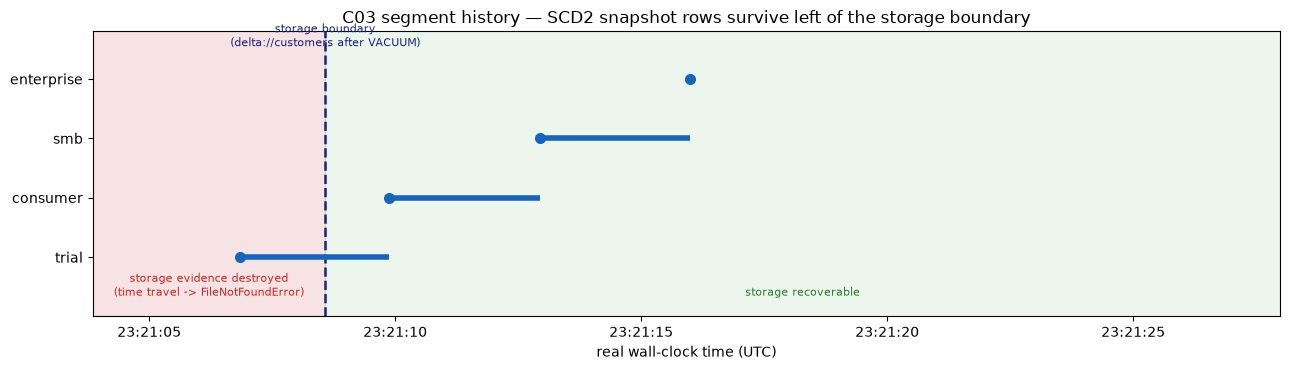

In [22]:
fig = ps.plot_v2(hist_c03, wm_customers, datetime.now(tz=timezone.utc))
assert (ps.IMG / 'v2_snapshot_vs_storage.png').exists()
print('saved img/v2_snapshot_vs_storage.png')

## S7b — weakest-link composition: which chain limits what?

**Claim.** A downstream model's effective boundary is the *most restrictive* upstream
boundary, and its effective grade the *weakest* grade on the path (spec §6).

- `fct_orders` composes `delta://orders` and `iceberg://raw.returns`; the Iceberg chain
  was truncated later, so **it** is the limiting link.
- `revenue_by_segment` adds `snapshot://customers_snapshot` — the youngest chain, whose
  boundary is its *first run* (witnesses are only ever minted in the present), so the
  snapshot limits the mart, and its `witnessed-fresh` grade drags the effective grade
  down from `derived`.

In [23]:
for rep in (report_fct, report_rbs):
    print(f"{rep.name}:")
    for wm in sorted(rep.upstreams, key=lambda w: w.boundary_dt):
        mark = ' <- limiting' if wm.chain == rep.limiting_chain else ''
        print(f"   {wm.chain:34s} boundary={wm.boundary_dt.isoformat()} "
              f"grade={wm.evidence_grade.value}{mark}")
    print(f"   effective grade: {rep.effective_grade.value}")
    print()
assert report_fct.limiting_chain == 'iceberg://raw.returns'
assert report_rbs.limiting_chain == 'snapshot://customers_snapshot'
assert report_rbs.effective_grade.value == 'witnessed-fresh'

fct_orders:
   delta://orders                     boundary=2026-07-07T23:20:45.609000+00:00 grade=derived
   iceberg://raw.returns              boundary=2026-07-07T23:21:02.528000+00:00 grade=derived <- limiting
   effective grade: derived

revenue_by_segment:
   delta://orders                     boundary=2026-07-07T23:20:45.609000+00:00 grade=derived
   iceberg://raw.returns              boundary=2026-07-07T23:21:02.528000+00:00 grade=derived
   snapshot://customers_snapshot      boundary=2026-07-07T23:21:06.851792+00:00 grade=witnessed-fresh <- limiting
   effective grade: witnessed-fresh



## The ledger itself

Everything above was recorded into an append-only, hash-chained JSONL manifest. The chain
verifies end to end; each entry commits to its predecessor's hash.

In [24]:
from alethe import Manifest

m = Manifest(ps.WATERMARKS)
print(m)
assert m.verify(), 'hash chain must verify'
for e in m.entries:
    subject = e.get('chain') or e.get('model')
    print(f"  seq={e['seq']:>2} prev={e['prev_hash'][:8]:>8} hash={e['hash'][:8]} "
          f"kind={e['kind']:26s} {subject}")

Manifest('watermarks.jsonl', 5 entries, INTACT)
  seq= 0 prev= GENESIS hash=9aa1c80b kind=watermark                  delta://orders
  seq= 1 prev=9aa1c80b hash=ff9106d4 kind=watermark                  iceberg://raw.returns
  seq= 2 prev=ff9106d4 hash=27d5bc4c kind=watermark                  delta://customers
  seq= 3 prev=27d5bc4c hash=a70a7fca kind=watermark                  snapshot://customers_snapshot
  seq= 4 prev=a70a7fca hash=eaa6bfd3 kind=materialization-snapshot   fct_orders


## What this notebook proved

| # | Scenario | Outcome (assertion-enforced above) |
|---|---|---|
| S1 | The lie | Log lists 22 versions; every write before v9 fails a real read |
| S2 | Oracle | Boundary v9, two independent derivations agree, read v9 OK / v8 fails; timestamp resolution into vacuumed versions shown deliberately |
| S3 | Reports | `alethe report` resolves every model via `meta.alethe.chain`; twice-temporal CONFORMANT from `run_results.json`; `alethe check` exit codes 1 → 0 with signed override |
| S4 | Rewrites | CERTAIN → clean Spark `TIMESTAMP AS OF` on both sources; BOUNDED → warning attached; UNACHIEVABLE → refusal by exception; snapshot upstream → SCD2 predicate, and the no-leaves mart refuses to pretend |
| S5 | Macro shim | Stock compile byte-identical; with vars: sources gain `AS OF`, snapshot ref becomes validity subquery |
| S6 | Snapshots vs storage | 7 of 20 days storage-unrecoverable (real read errors); SCD2 reconstructs all 20 |
| S7 | Weakest link | Iceberg suffix boundary + readable islands recorded but not claimed; Iceberg limits `fct_orders`, the snapshot chain (and its `witnessed-fresh` grade) limits the mart |

**The thesis, demonstrated end to end:** unknowability is a value, not an error — and
making the boundary legible is what lets *finite* retention be safe to rely on.